In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## **1. Average Blurring**

**What it is:** Average (box) blurring replaces every pixel with the *mean* value 
of its surrounding neighborhood (a kernel of size `width x height`). It's the 
simplest form of spatial smoothing — no weighting, every neighbor contributes equally.

**Why use it:**
- Reduces random noise by averaging it out.
- Softens harsh details/edges — useful as a lightweight preprocessing step.
- Fast and simple, making it a good baseline before trying Gaussian/Median/Bilateral.

**How it works:**
A sliding kernel (e.g. 5x5) moves across the image. For each pixel, OpenCV takes 
the average of all pixel values inside that kernel window and assigns it as the 
new value for the center pixel. Larger kernels = more neighboring pixels averaged 
= stronger blur, but more detail lost.

**About this script:**
This demo uses OpenCV trackbars to let you interactively control the kernel size:
- The `Width` and `Height` trackbars control `cv2.blur`'s kernel dimensions in real time.
- `+1` is added to both values because trackbars start at 0, and a `(0,0)` kernel 
  is invalid — you always need at least a `1x1` (identity) kernel.
- Press `q` to exit the live preview; the final blurred frame is then shown again 
  using `matplotlib` (note the `[..., ::-1]` — this converts OpenCV's BGR channel 
  order to RGB, since matplotlib expects RGB).

Width: 9
Height: 4


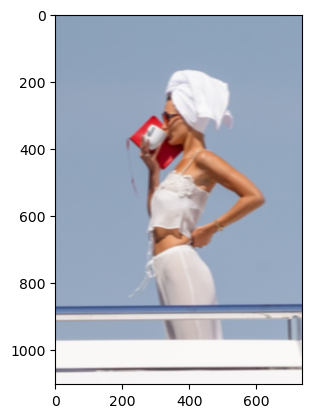

In [4]:
def nothing(x):
    pass

WINDOW = "Average Bluring"
cv2.namedWindow(WINDOW)
image = cv2.imread(r"C:\Users\DELL\Desktop\resources\ComputerVision\Computer Vision\Computer Vision Sessions\04s\pic04\bella.jfif")

cv2.createTrackbar("Width", WINDOW, 1, image.shape[1], nothing)
cv2.createTrackbar("Height", WINDOW, 1, image.shape[0], nothing)

while True:
    width = cv2.getTrackbarPos("Width", WINDOW)
    height = cv2.getTrackbarPos("Height", WINDOW)
    averaging_blur = cv2.blur(image, (width + 1, height + 1))
    
    cv2.imshow(WINDOW, averaging_blur)
    if cv2.waitKey(1) & 0xff == ord("q"):
        break

cv2.destroyAllWindows()
print(f"Width: {width}\nHeight: {height}")
plt.imshow(averaging_blur[..., ::-1])
plt.show()

## **2. Gaussian Blurring**

**What it is:** Unlike average blur (where every neighboring pixel contributes 
equally), Gaussian blur assigns weights to neighboring pixels based on a 
**2D Gaussian (normal distribution) function** — pixels closer to the center 
get more weight, pixels farther away get less. This produces a smoother, more 
natural-looking blur that mimics real optical defocus, rather than the "boxy" 
look of average blur.

---
### **The math**

The weight of a pixel at horizontal distance `x` and vertical distance `y` 
from the kernel's center is:

(`G(x, y) = (1 / (2π·σx·σy)) * e^( -( x²/(2σx²) + y²/(2σy²) ) )`)


- `σx` (**sigmaX**) controls how quickly influence fades **horizontally**
- `σy` (**sigmaY**) controls how quickly influence fades **vertically**
- Small `σ` → tall, narrow bell curve → sharp falloff → only very close pixels 
  matter → mild blur
- Large `σ` → short, wide bell curve → slow falloff → distant pixels matter 
  almost as much as the center → strong blur

If `sigmaY` is left at `0`, OpenCV just copies `sigmaX`, giving a symmetric, 
circular blur (the standard case).

---

### Syntax

```python
cv2.GaussianBlur(src, ksize, sigmaX, sigmaY=0, borderType=cv2.BORDER_DEFAULT)
```

| Argument | Meaning |
|---|---|
| `src` | Input image |
| `ksize` | `(width, height)` — kernel size. Must be **positive and odd** (single well-defined center pixel required) |
| `sigmaX` | Std. deviation controlling horizontal spread of the Gaussian. `0` → auto-calculated from `ksize` |
| `sigmaY` | Std. deviation controlling vertical spread. `0` → copies `sigmaX` |
| `borderType` | How pixels beyond the image edge are handled during convolution (e.g. `BORDER_DEFAULT`, `BORDER_REFLECT`, `BORDER_REPLICATE`, `BORDER_CONSTANT`) |

**Auto-sigma formula** (when `sigmaX=0`):

(`sigma = 0.3 * ((ksize - 1) * 0.5 - 1) + 0.8`)


**Rule of thumb:** kernel size and sigma should scale together — 
`sigma ≈ (ksize - 1) / 6` is a common guideline, covering ~±3 standard 
deviations (≈99.7% of the Gaussian's mass) within the kernel window

---

### When to use it
- General-purpose, natural-looking noise reduction
- Standard preprocessing step before edge detection (e.g. Canny)
- Simulating realistic optical blur / soft focus effects


Width: 7
Height: 9
sigmaX: 3
sigmaY: 1
borderType: 1


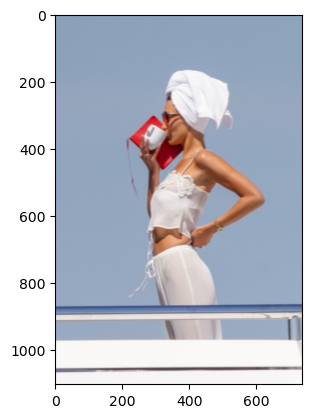

In [4]:
def nothing(x):
    pass

WINDOW = "Gaussian Blur"
cv2.namedWindow(WINDOW)
image = cv2.imread(r"C:\Users\DELL\Desktop\resources\ComputerVision\Computer Vision\Computer Vision Sessions\04s\pic04\bella.jfif")

cv2.createTrackbar("Width", WINDOW, 1, image.shape[1], nothing)
cv2.createTrackbar("Height", WINDOW, 1, image.shape[0], nothing)
cv2.createTrackbar("Sigma X", WINDOW, 0, 20, nothing)
cv2.createTrackbar("Sigma Y", WINDOW, 0, 20, nothing)
cv2.createTrackbar("Border Type", WINDOW, 0, 3, nothing)

while True:
    width = cv2.getTrackbarPos("Width", WINDOW)
    height = cv2.getTrackbarPos("Height", WINDOW)
    sigmaX = cv2.getTrackbarPos("Sigma X", WINDOW)
    sigmaY = cv2.getTrackbarPos("Sigma Y", WINDOW)
    borderType = cv2.getTrackbarPos("Border Type", WINDOW)

    match borderType:
        case 0:
            borderType = cv2.BORDER_DEFAULT
        case 1:
            borderType = cv2.BORDER_REFLECT
        case 2:
            borderType = cv2.BORDER_REPLICATE
        case 3:
            borderType = cv2.BORDER_CONSTANT
    
    if width % 2 == 0:
        width += 1
    if height % 2 == 0:
        height += 1

    gaussian_blur = cv2.GaussianBlur(image, (width, height), sigmaX=sigmaX, sigmaY=sigmaY, borderType=borderType)

    cv2.imshow(WINDOW, gaussian_blur)
    if cv2.waitKey(1) & 0xff == ord("q"):
        break

cv2.destroyAllWindows()
print(f"Width: {width}\nHeight: {height}\nsigmaX: {sigmaX}\nsigmaY: {sigmaY}\nborderType: {borderType}")
plt.imshow(gaussian_blur[..., ::-1])
plt.show()

## **3. Median Blurring**

**What it is:** Unlike average and Gaussian blur (which compute a *weighted 
mean* of the neighborhood), median blur replaces each pixel with the 
**median value** of its neighborhood — i.e., sort all pixel values in the 
kernel window and pick the middle one.

---
### **Why it's different from mean-based blurs**

Mean-based methods (average, Gaussian) are sensitive to outliers — a single 
extreme pixel value pulls the average toward it, effectively **smearing** 
noise into neighboring pixels rather than removing it.

Median is a **robust statistic**: an extreme outlier just gets sorted to the 
edge of the list and has **zero influence** on the result, as long as it's 
a minority within the neighborhood.

---

### **Why it excels at salt-and-pepper noise**

**Salt-and-pepper noise** = random individual pixels corrupted to pure white 
("salt") or pure black ("pepper"), scattered across an otherwise normal image 
— commonly from faulty sensors or transmission errors.

Since these corrupted pixels are:
1. Extreme in value (0 or 255), and
2. A small minority within any local neighborhood,

...they get pushed to the very ends of the sorted list and are effectively 
discarded by the median operation. This is why median blur is the standard, 
textbook choice for cleaning salt-and-pepper noise — it removes it outright, 
rather than blurring/spreading it like average or Gaussian blur would.

---
### **Syntax**

```python
cv2.medianBlur(src, ksize)
```

| Argument | Meaning |
|---|---|
| `src` | Input image |
| `ksize` | A single **odd integer** (not a tuple!) — e.g. `5` → 5x5 neighborhood |

---
### **When to use it**
- Salt-and-pepper / impulsive noise removal
- Cases where you need noise removal **without** smearing/blurring edges as 
  much as mean-based methods would

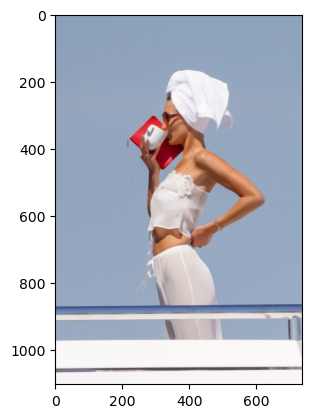

In [5]:
WINDOW = "Median Blur"
cv2.namedWindow(WINDOW)
image = cv2.imread(r"C:\Users\DELL\Desktop\resources\ComputerVision\Computer Vision\Computer Vision Sessions\04s\pic04\bella.jfif")

def implement_median_blur(ksize):
    global median_blur
    if ksize % 2 == 0:
        ksize += 1
    median_blur = cv2.medianBlur(image, ksize)
    cv2.imshow(WINDOW, median_blur)

cv2.createTrackbar("ksize", WINDOW, 1, min(image.shape[:2]), implement_median_blur)
implement_median_blur(0)

cv2.waitKey()
cv2.destroyAllWindows()   

plt.imshow(median_blur[..., ::-1])
plt.show()

## **4. Bilateral Filtering**

**What it is:** Bilateral filtering is a smoothing technique that blurs an 
image while **preserving edges** — something Gaussian and average blur can't 
do, since they blur everything equally regardless of content.

---
### **How it works (simple terms)**

For every neighboring pixel, bilateral filter asks two questions before 
deciding how much that neighbor should count:

1. **"How close is this pixel spatially?"** (same idea as Gaussian blur)
2. **"How similar is this pixel's color/intensity to the center pixel?"** (the new part)

It computes **two separate weights** — a spatial weight and a color-similarity 
weight — then **multiplies them together** to get the final weight used in a 
weighted mean:

(`final_weight = spatial_weight × color_weight`)

(`output_pixel = Σ(neighbor_value × final_weight) / Σ(final_weight)`)


Because of this multiplication, a pixel only gets real influence if it's 
**both** close in space **and** similar in color:

- Close + similar color (e.g. within flat skin/sky/wall) → strong influence → smoothed
- Close + very different color (e.g. across an edge) → weight collapses → **not** blurred

This is why bilateral filter smooths flat regions heavily while keeping sharp 
edges intact — pixels on the other side of an edge look "too different" to 
be blended in.

---
### **Syntax**

```python
cv2.bilateralFilter(src, d, sigmaColor, sigmaSpace, borderType=cv2.BORDER_DEFAULT)
```

| Argument | Meaning |
|---|---|
| `src` | Input image |
| `d` | Diameter of the pixel neighborhood. Use a small positive value (e.g. `5–9`) for real-time use, or `<= 0` to auto-compute `d` from `sigmaSpace` |
| `sigmaColor` | How much color/intensity difference is tolerated as "similar." Small (`~10-30`) → strict, only near-identical colors blend; large (`~100+`) → tolerant, starts behaving like plain Gaussian blur |
| `sigmaSpace` | How far spatially a pixel can be and still count. Same role as sigma in Gaussian blur |

**Common starting point (OpenCV's own suggested default):** `sigmaColor = 75`, `sigmaSpace = 75`. Values below ~30 for `sigmaColor` often produce **no visible blur at all**, since real image noise/texture usually exceeds that threshold and gets rejected as "too different."

---
### **Use cases**
- Skin smoothing (beauty filters) — smooths skin while keeping facial features sharp
- Cartoon/stylization effects (often paired with edge detection)
- Denoising **before** segmentation or edge detection, where you need edges to stay crisp
- Any case where you want noise reduction **without** the softened, blurry look of Gaussian blur

---
### **Trade-off**
Much more computationally expensive than average/Gaussian/median blur, since 
it computes a second weight per pixel per neighbor — not ideal for real-time 
use on large images without optimization.

In [ ]:
WINDOW = "Bilateral BLur"
cv2.namedWindow(WINDOW)
image = cv2.imread(r"C:\Users\DELL\Desktop\resources\ComputerVision\Computer Vision\Computer Vision Sessions\04s\pic04\bella.jfif")

def nothing(x):
    pass

cv2.createTrackbar("d", WINDOW, 0, 9, nothing)
cv2.createTrackbar("sigma color", WINDOW, 50, 200, nothing)
cv2.createTrackbar("sigma space", WINDOW, 50, 200, nothing)

while True:
    d = cv2.getTrackbarPos("d", WINDOW)
    sigma_color = cv2.getTrackbarPos("sigma color", WINDOW)
    sigma_space = cv2.getTrackbarPos("sigma space", WINDOW)

    bilateral_blur = cv2.bilateralFilter(image, d, sigma_color, sigma_space)
    cv2.imshow(WINDOW, bilateral_blur)
    if cv2.waitKey(1) & 0xff == ord("q"):
        break

cv2.destroyAllWindows()
plt.imshow(bilateral_blur[..., ::-1])
plt.show()

## **5. Motion Blur**

**What it is:** Unlike average, Gaussian, median, and bilateral blur — which 
all spread influence in a square/circular neighborhood around each pixel — 
motion blur spreads influence **only along one direction**, simulating the 
smear that happens when a camera or subject moves during exposure.

There's no dedicated OpenCV function for this — you build the kernel manually, 
then apply it with `cv2.filter2D`.

---
### **What's happening under the hood**

The kernel is a small square matrix, mostly filled with `0`s, except for a 
**single line of equal values** running through its center in the direction 
you want the blur to travel:

(`0 0 0 0 0
0 0 0 0 0
1/5 1/5 1/5 1/5 1/5 ← the "motion line" (center row)
0 0 0 0 0
0 0 0 0 0`)


When this kernel convolves over the image, each output pixel becomes the 
**average of the pixels lying along that line** — pulling in pixels from 
along the direction of motion, while completely ignoring pixels off that 
line (since their weight is `0`). 

This is the *same underlying mechanism* as average blur (a normalized kernel 
computing a mean) — just reshaped from a square into a line, so averaging 
only happens along one axis instead of radiating outward equally in all 
directions.

- **Horizontal line** in the kernel → horizontal motion blur (e.g. a car driving sideways)
- **Vertical line** → vertical motion blur (e.g. something falling)
- **Diagonal line** → diagonal motion blur (e.g. angled camera shake)
- **Longer line (bigger kernel)** → longer, stronger streak
- **Shorter line** → subtle blur

---
### **Building the kernel, step by step**

```python
import numpy as np

size = 15                                          # streak length (your choice, NOT tied to image size)
kernel = np.zeros((size, size))                     # step 1: blank size x size canvas of zeros
kernel[int((size - 1) / 2), :] = np.ones(size)       # step 2: fill the center row with 1s
kernel = kernel / size                              # step 3: normalize so values sum to 1
```

1. **`size`** — choose a small number (commonly `9`–`31`) that controls how long the motion streak looks. This is independent of the image's actual resolution — a kernel must stay small and local, never as large as the image itself.
2. **`np.zeros((size, size))`** — creates a blank `size x size` matrix of all `0`s. A `0` weight means "this pixel contributes nothing."
3. **`kernel[int((size-1)/2), :] = np.ones(size)`** — selects the exact center row (`int((size-1)/2)` finds the middle index) and fills the entire row with `1`s, forming the "motion line."
4. **`kernel / size`** — normalizes the values so they sum to `1`. Without this, the output would be a raw *sum* of `size` pixel values instead of their average — producing a blown-out, overly bright image.

**For vertical motion instead of horizontal**, swap which axis the line is drawn on:
```python
kernel[:, int((size - 1) / 2)] = np.ones(size)   # fills the center COLUMN instead of the center row
```
---
### **Syntax**

```python
cv2.filter2D(src, ddepth, kernel)
```

| Argument | Meaning |
|---|---|
| `src` | Input image |
| `ddepth` | Output image depth. Use `-1` to keep the same depth as the input (standard choice) |
| `kernel` | The custom convolution matrix you built manually (the "motion line" kernel) |

---
### **Use cases**
- **Data augmentation** — training detection/classification models to be robust to real-world motion blur (sports footage, traffic cams, handheld video)
- **Artistic/cinematic effects** — adding a sense of speed or movement to static images
- **Testing model robustness** — deliberately degrading images to measure how much accuracy drops under motion blur
- **Simulating camera shake** — for realism in synthetic or rendered scenes

---
### **Key takeaway**
Motion blur = average blur's exact same math (normalized kernel, weighted mean), just reshaped from a **square** into a **line**, so averaging happens only along one direction instead of spreading equally in every direction.

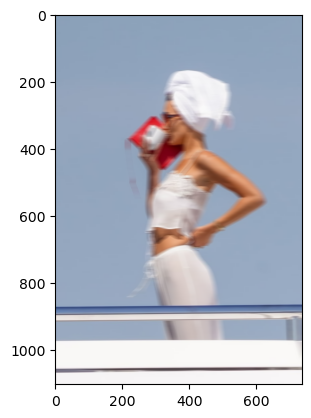

In [18]:
size=20
kernel = np.zeros((20, 20))
kernel[int((size - 1) / 2), :] = np.ones(size)
kernel /=size

motion_blur = cv2.filter2D(image, -1, kernel)

plt.imshow(motion_blur[..., ::-1])
plt.show()